# model 학습
| 모델                                   | 특징                          | 추천 이유                        |
| ------------------------------------ | --------------------------- | ---------------------------- |
| **Random Forest**                    | 비선형 분류 + Feature Importance | 샘플 수 적정, 해석 가능, 과적합에 강함      |
| **XGBoost**                          | 비선형, 성능 최적화, 불균형 대응         | 가중치 조절, 고성능, SHAP 분석 가능      |
| **SVC (RBF 커널)**                     | 비선형 경계 학습                   | t-SNE/UMAP 분포에서 효과적          |
| **Logistic Regression (ElasticNet)** | 선형 + 해석 가능                  | 해석력 우선시 시도 (PLS/PCA에서 분리될 때) |
| **K-Nearest Neighbors (KNN)**        | 지역기반 비선형                    | UMAP에서 국지적 패턴 분명할 때 유용       |


## ===============================

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 경로 설정
save_dir = "/Users/taehokim/lab/BRL_AI/위생방_TBARS추가/"

# 1. 변화율 Top 10 feature 데이터 불러오기
top10_data_path = os.path.join(save_dir, "all_top10_data.pkl")
with open(top10_data_path, 'rb') as f:
    all_top10_data = pickle.load(f)

# 2. 변화율 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
with open(change_analysis_path, 'rb') as f:
    change_analysis_results = pickle.load(f)

## 1. TPC 먼저 모델 학습

In [2]:
# 3. TPC 라벨 생성 및 데이터 준비

# TPC 최적 임계값 설정
TPC_THR_LOW = 4.253
TPC_THR_HIGH = 6.324

# 라벨 생성 함수
def create_tpc_labels(df, tpc_col='TPC (log CFU/g)', 
                      tpc_low=TPC_THR_LOW, tpc_high=TPC_THR_HIGH):
    """TPC 값을 기준으로 라벨 생성"""
    conditions = [
        df[tpc_col] < tpc_low,      # Fresh
        df[tpc_col] >= tpc_high,    # Decay
    ]
    choices = [0, 1]  # Fresh=0, Decay=1
    labels = np.select(conditions, choices, default=2)  # Middle=2
    return labels

# 라벨명 매핑
LABEL_NAMES = {0: 'Fresh', 1: 'Decay', 2: 'Middle'}
LABEL_COLORS = {0: 'green', 1: 'red', 2: 'orange'}

# 4. 모든 taxonomy level에 라벨 추가 (Top 10 feature만 사용)
final_taxonomic_levels_with_label = []

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    top10_df = all_top10_data[level_name]['top10_data'].copy()
    # 라벨 생성
    top10_df['Label'] = create_tpc_labels(top10_df)
    # Day 컬럼 추가
    top10_df['Day'] = top10_df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    final_taxonomic_levels_with_label.append((level_name, top10_df))

    print(f"\n=== {level_name} Level ===")
    print(f"Shape: {top10_df.shape}")
    feature_cols = all_top10_data[level_name]['top_10_feature_names']
    print(f"미생물 Feature 수: {len(feature_cols)}")
    label_counts = np.bincount(top10_df['Label'])
    total = len(top10_df)
    for i, count in enumerate(label_counts):
        name = LABEL_NAMES[i]
        percentage = count / total * 100
        print(f"{name}: {count}개 ({percentage:.1f}%)")

print(f"\n=== 라벨 생성 완료 ===")
print(f"임계값: Fresh < {TPC_THR_LOW}, Decay ≥ {TPC_THR_HIGH}")


=== Phylum Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 143개 (53.0%)
Decay: 42개 (15.6%)
Middle: 85개 (31.5%)

=== Class Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 143개 (53.0%)
Decay: 42개 (15.6%)
Middle: 85개 (31.5%)

=== Order Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 143개 (53.0%)
Decay: 42개 (15.6%)
Middle: 85개 (31.5%)

=== Family Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 143개 (53.0%)
Decay: 42개 (15.6%)
Middle: 85개 (31.5%)

=== Genus Level ===
Shape: (270, 15)
미생물 Feature 수: 10
Fresh: 143개 (53.0%)
Decay: 42개 (15.6%)
Middle: 85개 (31.5%)

=== 라벨 생성 완료 ===
임계값: Fresh < 4.253, Decay ≥ 6.324


# TPC 모델 학습

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 사용할 모델과 파라미터 그리드 정의 (Pipeline 적용, prefix 적용)
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },
    "SVC": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC())
        ]),
        "params": {
            "svc__C": [0.5, 1, 2],
            "svc__gamma": ["scale", "auto"],
            "svc__kernel": ["rbf"],
            "svc__probability": [True],
            "svc__class_weight": ["balanced"]
        }
    },
    "LogisticRegression": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression())
        ]),
        "params": {
            "lr__penalty": ["elasticnet"],
            "lr__solver": ["saga"],
            "lr__l1_ratio": [0.2, 0.5, 0.8],
            "lr__C": [0.5, 1, 2],
            "lr__max_iter": [500],
            "lr__class_weight": ["balanced"],
            "lr__multi_class": ["multinomial"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier,
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    }
}
taxonomy_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# 결과 저장 딕셔너리
all_model_results = {}

for level_name in taxonomy_levels:
    print(f"\n{'='*60}\n=== {level_name} Level 모델 학습 시작 ===\n{'='*60}")
    level_data = final_taxonomic_levels_with_label[[x[0] for x in final_taxonomic_levels_with_label].index(level_name)][1]
    feature_cols = [col for col in level_data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
    X = level_data[feature_cols].values
    y = level_data['Label'].values

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    all_model_results[level_name] = {}

    for model_name, config in model_configs.items():
        print(f"\n--- {model_name} 학습 ---")
        # Pipeline/lambda는 함수로, 나머지는 클래스이므로 항상 ()로 인스턴스 생성
        model = config["model"]() if callable(config["model"]) else config["model"]()
        param_grid = config["params"]

        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_

        # 예측 및 평가
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')
        test_f1 = f1_score(y_test, y_test_pred, average='macro')
        overfit_acc = train_acc - test_acc
        overfit_f1 = train_f1 - test_f1

        # 결과 저장
        all_model_results[level_name][model_name] = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_f1_score": train_f1,
            "test_f1_score": test_f1,
            "Overfitting_Acc": overfit_acc,
            "Overfitting_F1": overfit_f1,
            "Best_Params": best_params,
            "Best_Model": best_model,
            "GridSearchCV": grid  # grid 객체도 저장
        }

        print(f"Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")
        print(f"Train F1: {train_f1:.3f}, Test F1: {test_f1:.3f}")
        print(f"Overfitting Acc: {overfit_acc:.3f}, Overfitting F1: {overfit_f1:.3f}")
        print(f"Best Params: {best_params}")

print("\n=== 모든 모델 학습 및 평가 완료 ===")

# GridSearchCV로 찾은 하이퍼파라미터 전체 출력
print("\n===== GridSearchCV Best Params 전체 출력 =====")
for level_name in taxonomy_levels:
    print(f"\n[{level_name}]")
    for model_name in model_configs.keys():
        params = all_model_results[level_name][model_name]["Best_Params"]
        print(f"{model_name}: {params}")


=== Phylum Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.889, Test Acc: 0.722
Train F1: 0.852, Test F1: 0.597
Overfitting Acc: 0.167, Overfitting F1: 0.255
Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.940, Test Acc: 0.796
Train F1: 0.934, Test F1: 0.734
Overfitting Acc: 0.144, Overfitting F1: 0.200
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.801, Test Acc: 0.630
Train F1: 0.755, Test F1: 0.514
Overfitting Acc: 0.171, Overfitting F1: 0.241
Best Params: {'svc__C': 2, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf', 'svc__probability': True}

--- LogisticRegression 학습 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.755, Test Acc: 0.648
Train F1: 0.699, Test F1: 0.541
Overfitting Acc: 0.106, Overfitting F1: 0.158
Best Params: {'lr__C': 2, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.861, Test Acc: 0.722
Train F1: 0.816, Test F1: 0.665
Overfitting Acc: 0.139, Overfitting F1: 0.151
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}

=== Class Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.986, Test Acc: 0.704
Train F1: 0.985, Test F1: 0.579
Overfitting Acc: 0.282, Overfitting F1: 0.406
Best Params: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.995, Test Acc: 0.741
Train F1: 0.996, Test F1: 0.649
Overfitting Acc: 0.255, Overfitting F1: 0.347
Best Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.759, Test Acc: 0.611
Train F1: 0.723, Test F

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.750, Test Acc: 0.630
Train F1: 0.700, Test F1: 0.551
Overfitting Acc: 0.120, Overfitting F1: 0.150
Best Params: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.5, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.995, Test Acc: 0.648
Train F1: 0.996, Test F1: 0.598
Overfitting Acc: 0.347, Overfitting F1: 0.398
Best Params: {'n_neighbors': 7, 'weights': 'distance'}

=== Order Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.949, Test Acc: 0.778
Train F1: 0.947, Test F1: 0.718
Overfitting Acc: 0.171, Overfitting F1: 0.228
Best Params: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.944, Test Acc: 0.778
Train F1: 0.939, Test F1: 0.731
Overfitting Acc: 0.167, Overfitting F1: 0.208
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.843, Test Acc: 0.741
Train F1: 0.797, Test 

...

Train Acc: 0.815, Test Acc: 0.722
Train F1: 0.773, Test F1: 0.662
Overfitting Acc: 0.093, Overfitting F1: 0.111
Best Params: {'lr__C': 1, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.819, Test Acc: 0.722
Train F1: 0.770, Test F1: 0.634
Overfitting Acc: 0.097, Overfitting F1: 0.136
Best Params: {'n_neighbors': 7, 'weights': 'uniform'}

=== Family Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.907, Test Acc: 0.796
Train F1: 0.887, Test F1: 0.758
Overfitting Acc: 0.111, Overfitting F1: 0.129
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.977, Test Acc: 0.833
Train F1: 0.980, Test F1: 0.783
Overfitting Acc: 0.144, Overfitting F1: 0.197
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.894, Test Acc: 0.870
Train F1: 0.863, Test 

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.894, Test Acc: 0.815
Train F1: 0.871, Test F1: 0.766
Overfitting Acc: 0.079, Overfitting F1: 0.105
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.995, Test Acc: 0.870
Train F1: 0.996, Test F1: 0.840
Overfitting Acc: 0.125, Overfitting F1: 0.156
Best Params: {'n_neighbors': 5, 'weights': 'distance'}

=== Genus Level 모델 학습 시작 ===

--- RandomForest 학습 ---
Train Acc: 0.907, Test Acc: 0.815
Train F1: 0.887, Test F1: 0.784
Overfitting Acc: 0.093, Overfitting F1: 0.103
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.995, Test Acc: 0.796
Train F1: 0.996, Test F1: 0.736
Overfitting Acc: 0.199, Overfitting F1: 0.260
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.875, Test Acc: 0.852
Train F1: 0.849, Test

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.875, Test Acc: 0.833
Train F1: 0.856, Test F1: 0.793
Overfitting Acc: 0.042, Overfitting F1: 0.064
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.866, Test Acc: 0.889
Train F1: 0.837, Test F1: 0.854
Overfitting Acc: -0.023, Overfitting F1: -0.017
Best Params: {'n_neighbors': 5, 'weights': 'uniform'}

=== 모든 모델 학습 및 평가 완료 ===

===== GridSearchCV Best Params 전체 출력 =====

[Phylum]
RandomForest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
SVC: {'svc__C': 2, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf', 'svc__probability': True}
LogisticRegression: {'lr__C': 2, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet'

## TPC 모델 성능 결과 엑셀 파일에 저장

In [4]:
import os
import pandas as pd

# 디렉토리 생성
result_dir = "model_result"
os.makedirs(result_dir, exist_ok=True)

# 모델 및 taxonomy level 순서 정의 (실제 코드에서 쓰는 이름과 일치시켜야 함)
model_order = [
    "RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"
]
taxonomy_order = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# 결과 DataFrame 생성
result_rows = []
for level_name, model_dict in all_model_results.items():
    for model_name, res in model_dict.items():
        row = {
            "Model": model_name,
            "Level": level_name,
            "Train_Accuracy": res["train_accuracy"],
            "Test_Accuracy": res["test_accuracy"],
            "F1_Macro": res["train_f1_score"],  # train F1
            "Overfitting_Acc": res["Overfitting_Acc"],
            "Overfitting_F1": res["Overfitting_F1"],
            "Best_Params": str(res["Best_Params"])  # 파라미터 추가
        }
        result_rows.append(row)

df_result = pd.DataFrame(result_rows)

# 컬럼 순서
df_result = df_result[[
    "Model", "Level", "Train_Accuracy", "Test_Accuracy", "F1_Macro", "Overfitting_Acc", "Overfitting_F1", "Best_Params"
]]

# Overfitting 위험도 컬럼 추가
def overfit_flag(row):
    if abs(row["Overfitting_Acc"]) < 0.15 and abs(row["Overfitting_F1"]) < 0.15:
        return "🟩 Low"
    elif abs(row["Overfitting_Acc"]) < 0.3 and abs(row["Overfitting_F1"]) < 0.3:
        return "🟨 Caution"
    else:
        return "🟥 High"

df_result["Overfitting_Flag"] = df_result.apply(overfit_flag, axis=1)

# 모델명 표기 통일 (실제 코드에서 쓰는 이름과 동일하게)
model_name_map = {
    "RandomForest": "RandomForest",
    "XGBoost": "XGBoost",
    "SVC": "SVC",
    "LogisticRegression": "LogisticRegression",
    "KNN": "KNN"
}
df_result["Model"] = df_result["Model"].map(model_name_map).fillna(df_result["Model"])

# 정렬
df_result["Model"] = pd.Categorical(df_result["Model"], categories=model_order, ordered=True)
df_result["Level"] = pd.Categorical(df_result["Level"], categories=taxonomy_order, ordered=True)
df_result = df_result.sort_values(["Model", "Level"]).reset_index(drop=True)

# 엑셀로 저장
excel_path = os.path.join(result_dir, "tpc_model_result.xlsx")
df_result.to_excel(excel_path, index=False)

print(f"모델 성능 결과가 '{excel_path}'에 저장되었습니다.")

모델 성능 결과가 'model_result/tpc_model_result.xlsx'에 저장되었습니다.


## TPC 모델 과적합 검증

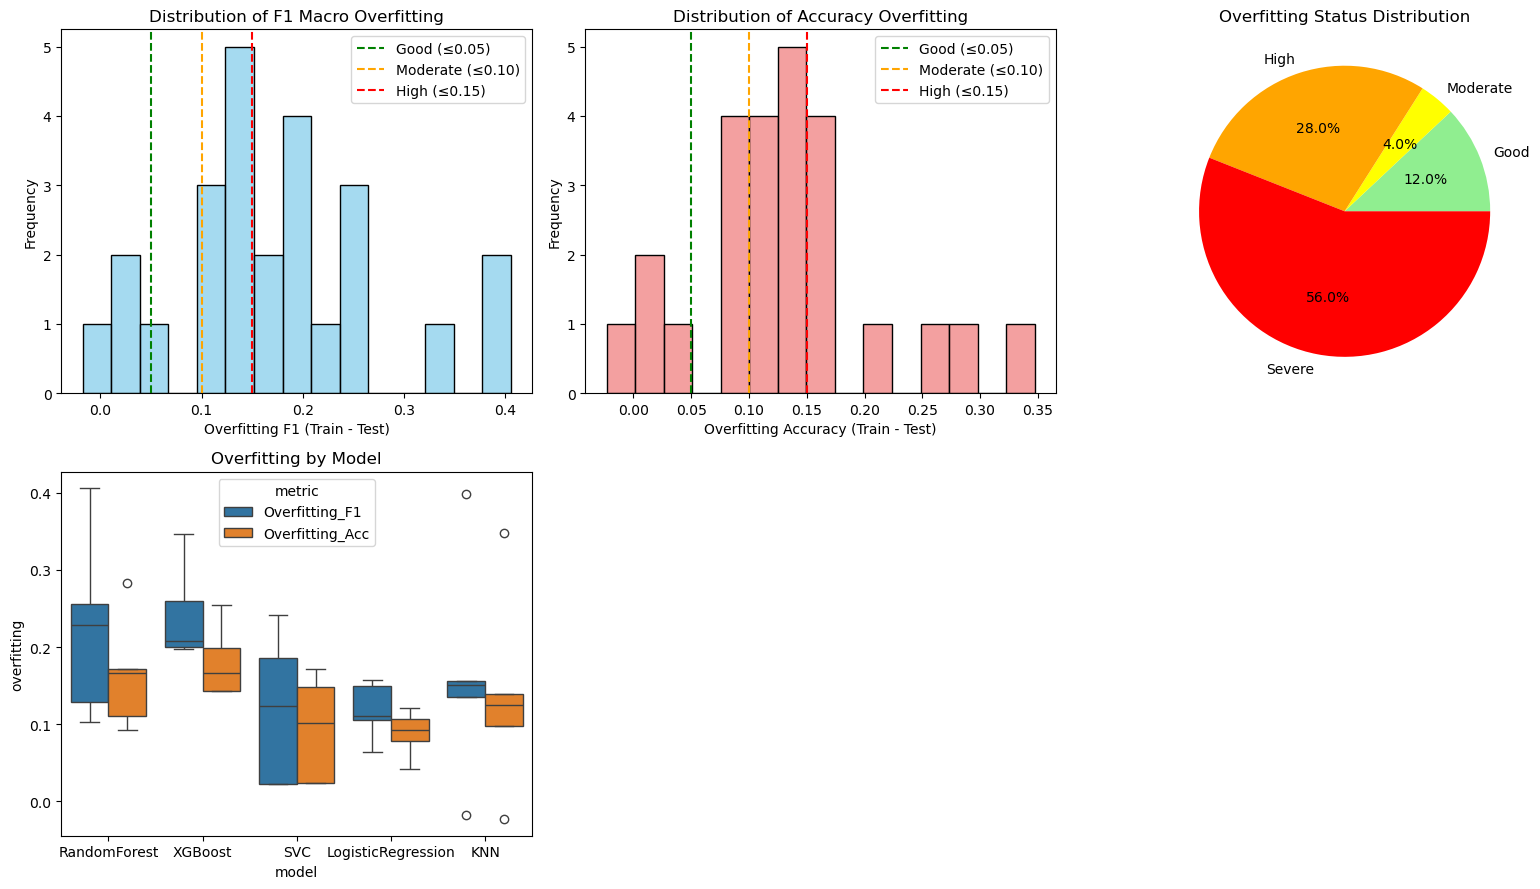

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 오버피팅 상태 분류 함수 (이미지 기준)
def overfit_status(row):
    # Good: ≤0.05, Moderate: ≤0.10, High: ≤0.15, Severe: >0.15
    max_gap = max(abs(row["Overfitting_Acc"]), abs(row["Overfitting_F1"]))
    if max_gap <= 0.05:
        return "Good"
    elif max_gap <= 0.10:
        return "Moderate"
    elif max_gap <= 0.15:
        return "High"
    else:
        return "Severe"

df_result["Overfit_Status"] = df_result.apply(overfit_status, axis=1)

plt.figure(figsize=(16, 9))

# 1. F1 Macro Overfitting 분포
plt.subplot(2, 3, 1)
sns.histplot(df_result["Overfitting_F1"], bins=15, color="skyblue", kde=False)
plt.axvline(0.05, color='g', linestyle='--', label='Good (≤0.05)')
plt.axvline(0.10, color='orange', linestyle='--', label='Moderate (≤0.10)')
plt.axvline(0.15, color='r', linestyle='--', label='High (≤0.15)')
plt.title("Distribution of F1 Macro Overfitting")
plt.xlabel("Overfitting F1 (Train - Test)")
plt.ylabel("Frequency")
plt.legend()

# 2. Accuracy Overfitting 분포
plt.subplot(2, 3, 2)
sns.histplot(df_result["Overfitting_Acc"], bins=15, color="lightcoral", kde=False)
plt.axvline(0.05, color='g', linestyle='--', label='Good (≤0.05)')
plt.axvline(0.10, color='orange', linestyle='--', label='Moderate (≤0.10)')
plt.axvline(0.15, color='r', linestyle='--', label='High (≤0.15)')
plt.title("Distribution of Accuracy Overfitting")
plt.xlabel("Overfitting Accuracy (Train - Test)")
plt.ylabel("Frequency")
plt.legend()

# 3. 오버피팅 상태 파이차트
plt.subplot(2, 3, 3)
status_counts = df_result["Overfit_Status"].value_counts().reindex(["Good", "Moderate", "High", "Severe"], fill_value=0)
colors = ["lightgreen", "yellow", "orange", "red"]
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=colors)
plt.title("Overfitting Status Distribution")

# 4. 모델별 오버피팅 boxplot
plt.subplot(2, 3, 4)
df_melt = df_result.melt(id_vars=["Model"], value_vars=["Overfitting_F1", "Overfitting_Acc"], 
                         var_name="metric", value_name="overfitting")
sns.boxplot(data=df_melt, x="Model", y="overfitting", hue="metric")
plt.title("Overfitting by Model")
plt.xlabel("model")
plt.ylabel("overfitting")

plt.tight_layout()
plt.show()

## TPC 모델 성능 평가

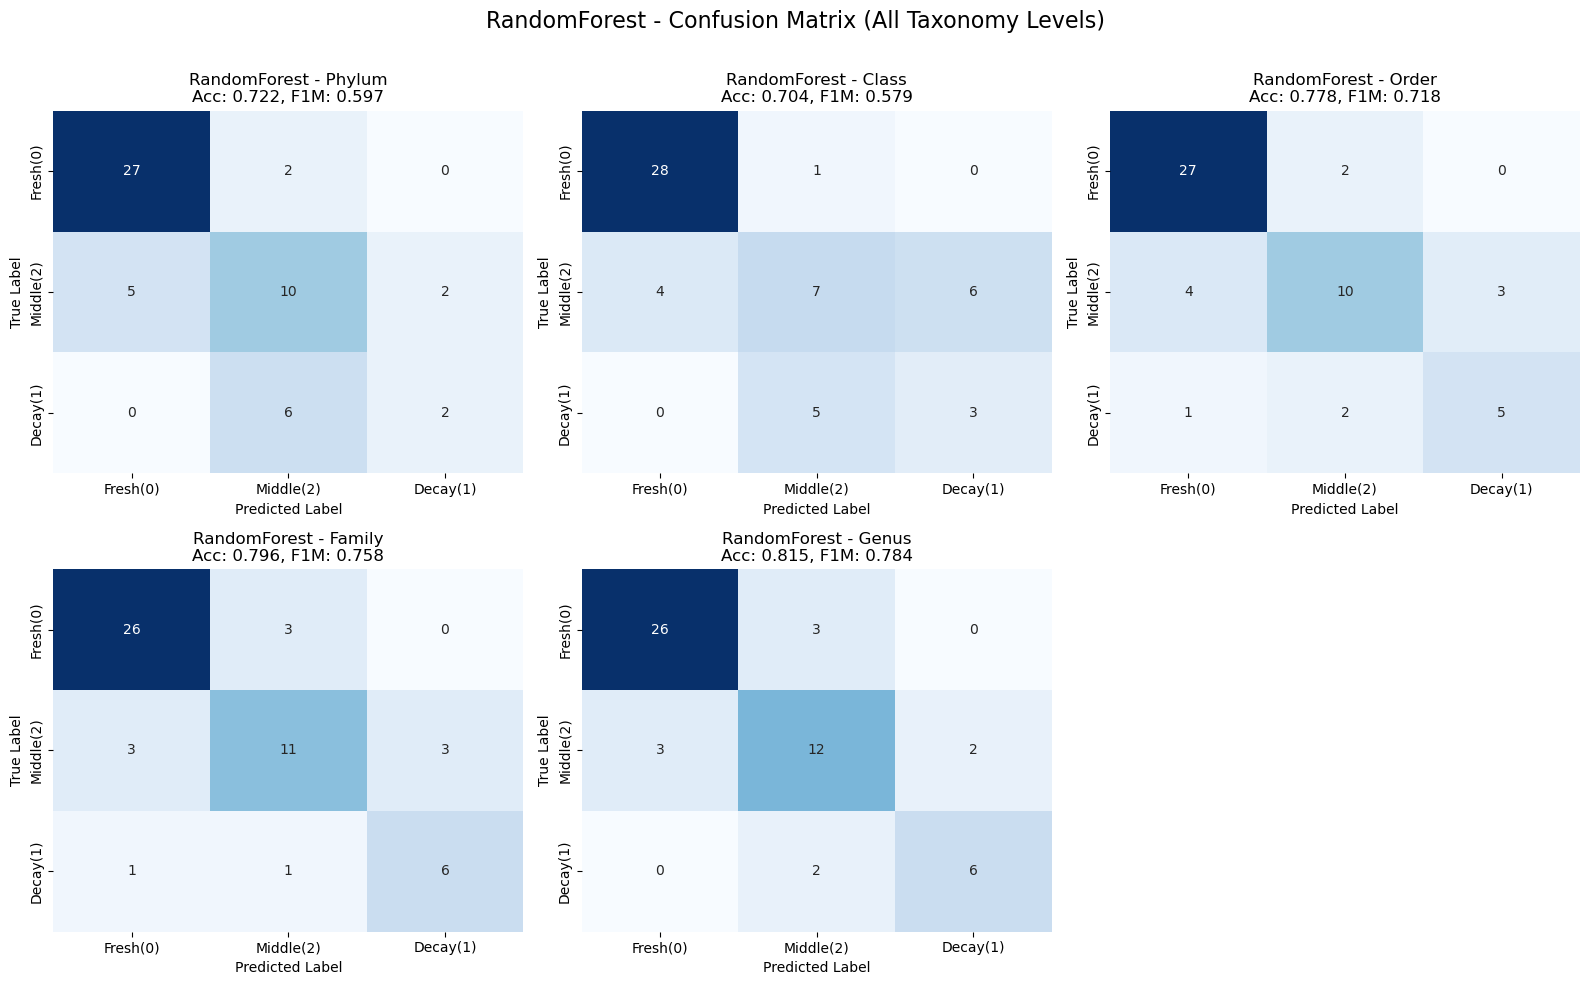

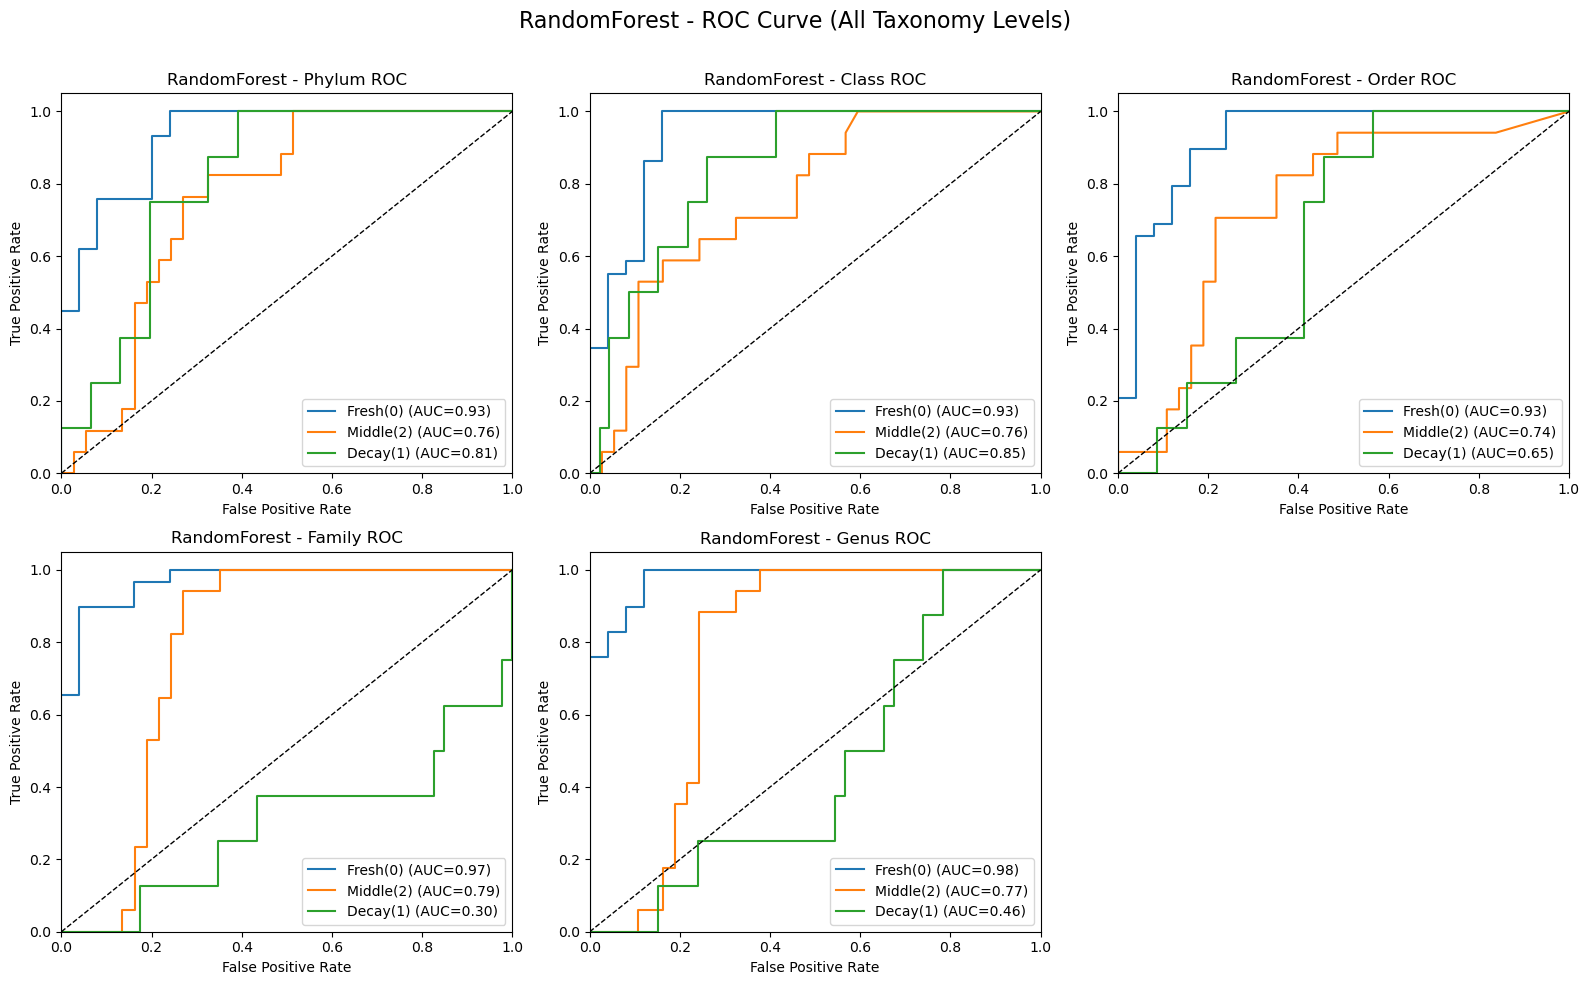

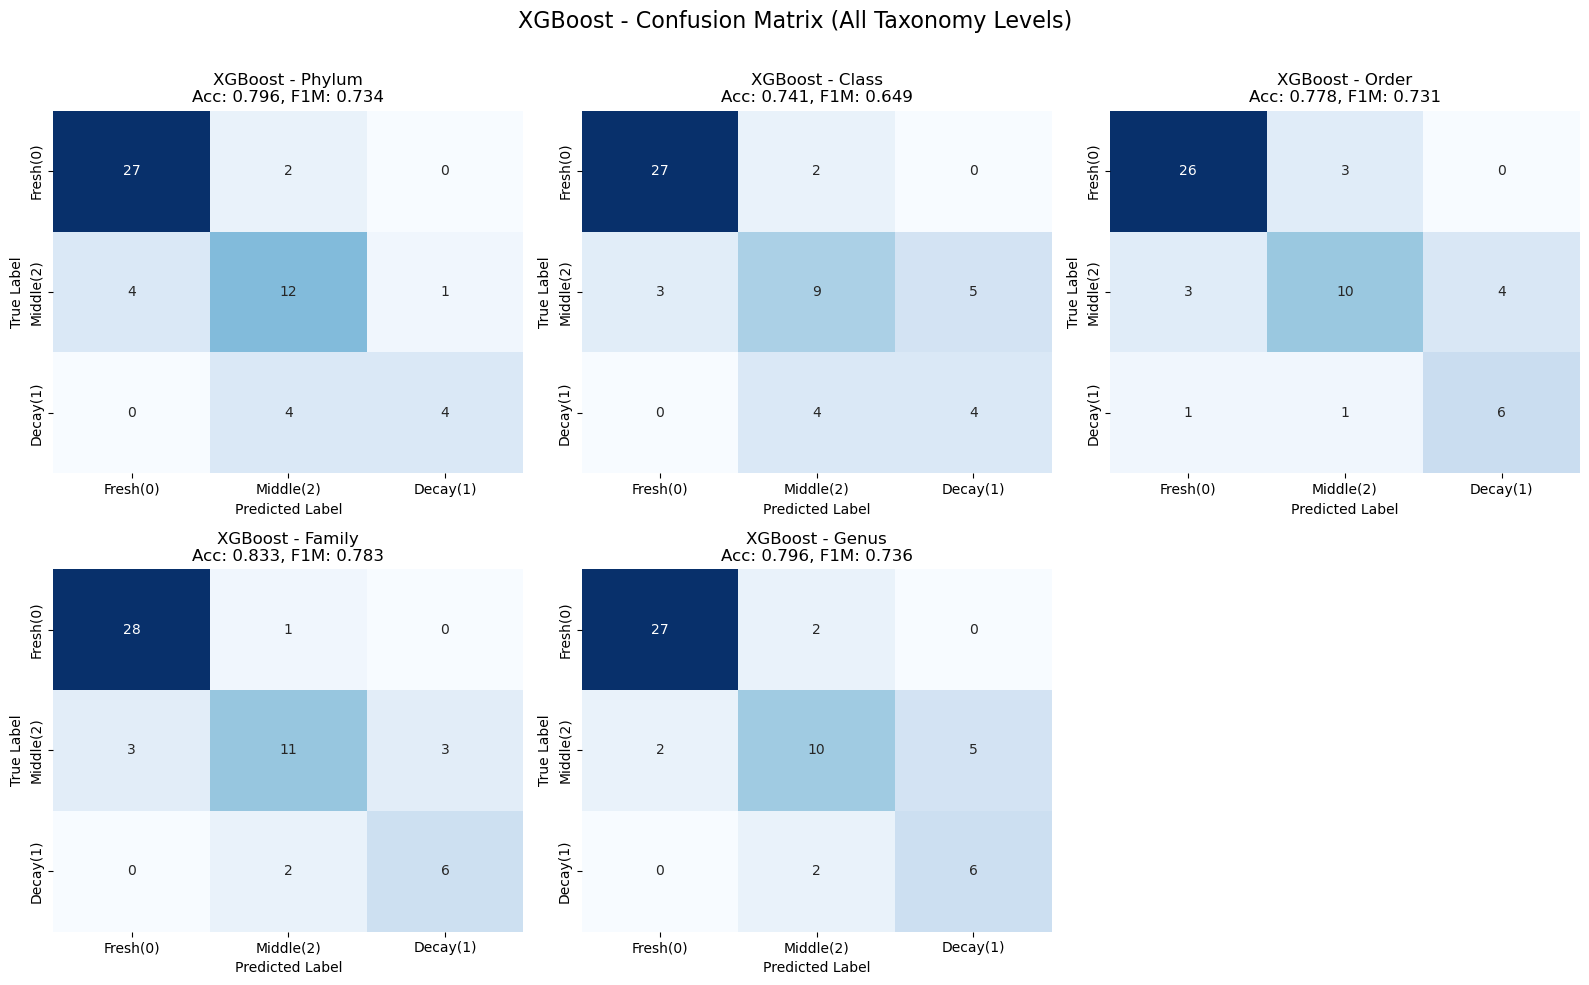

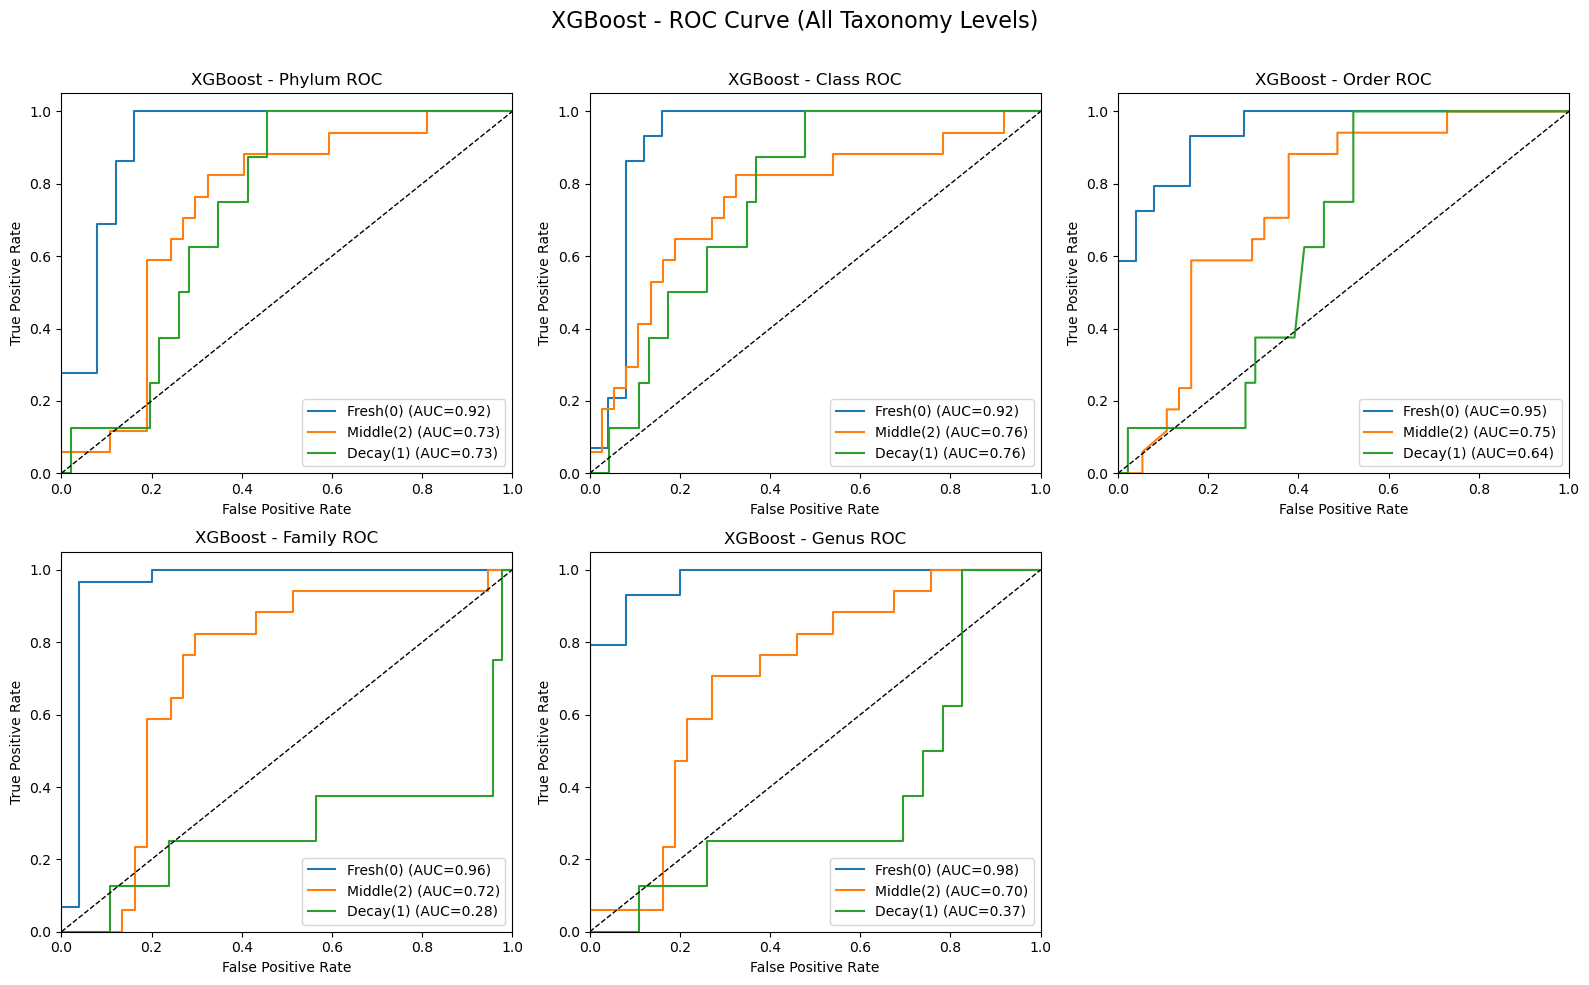

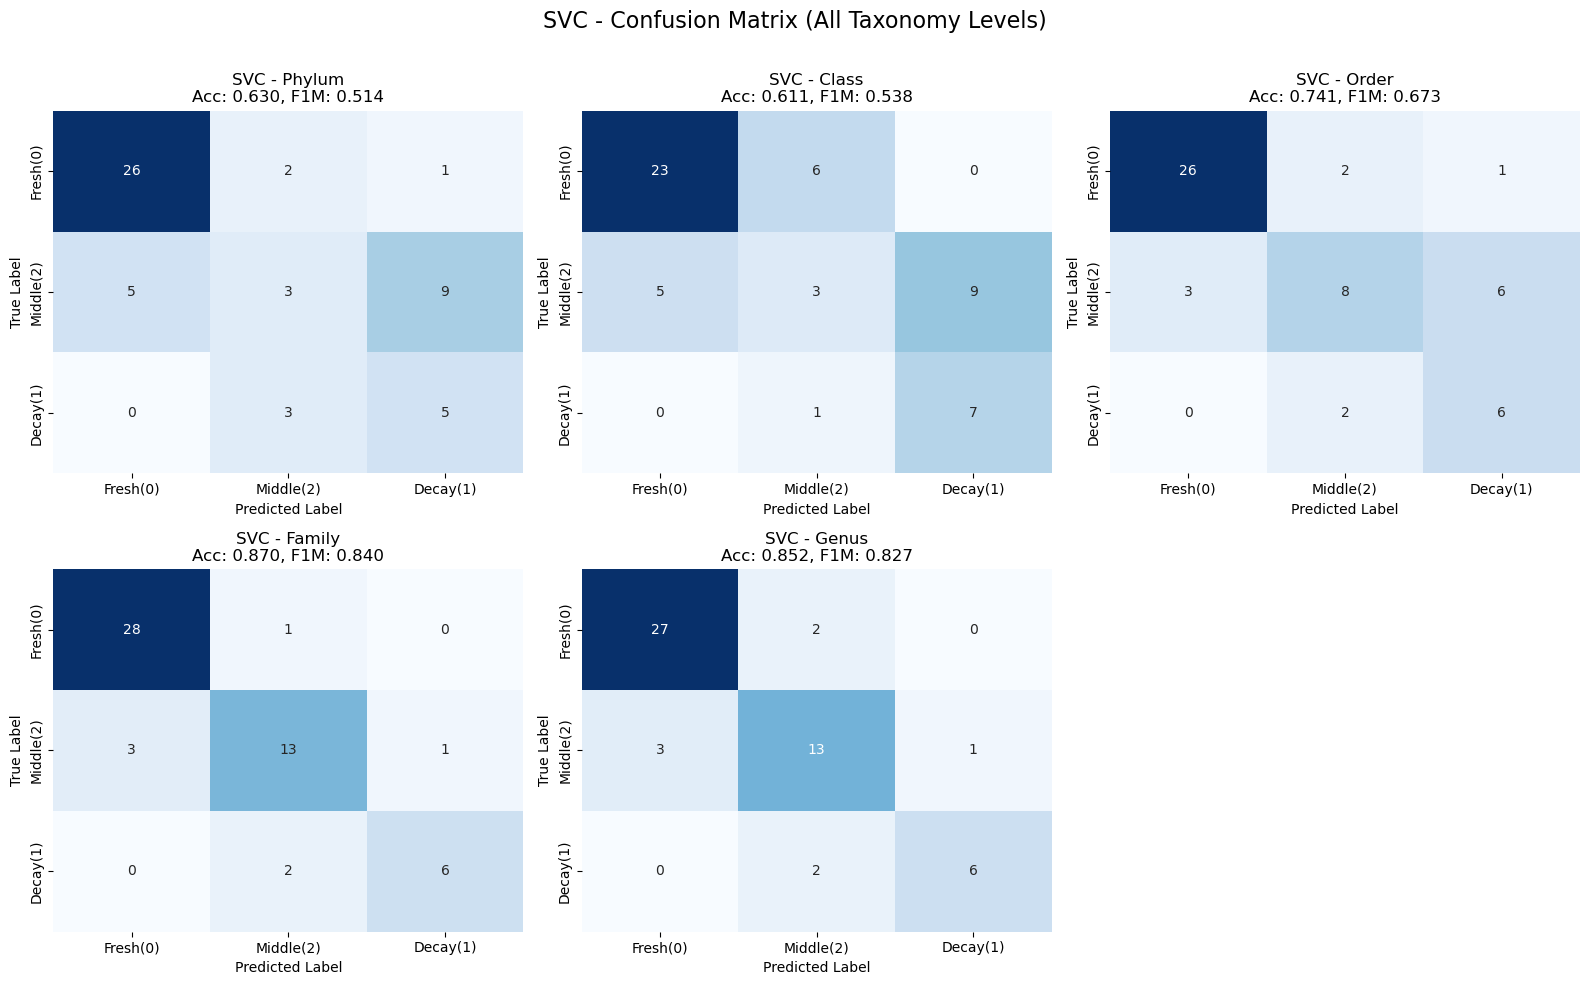

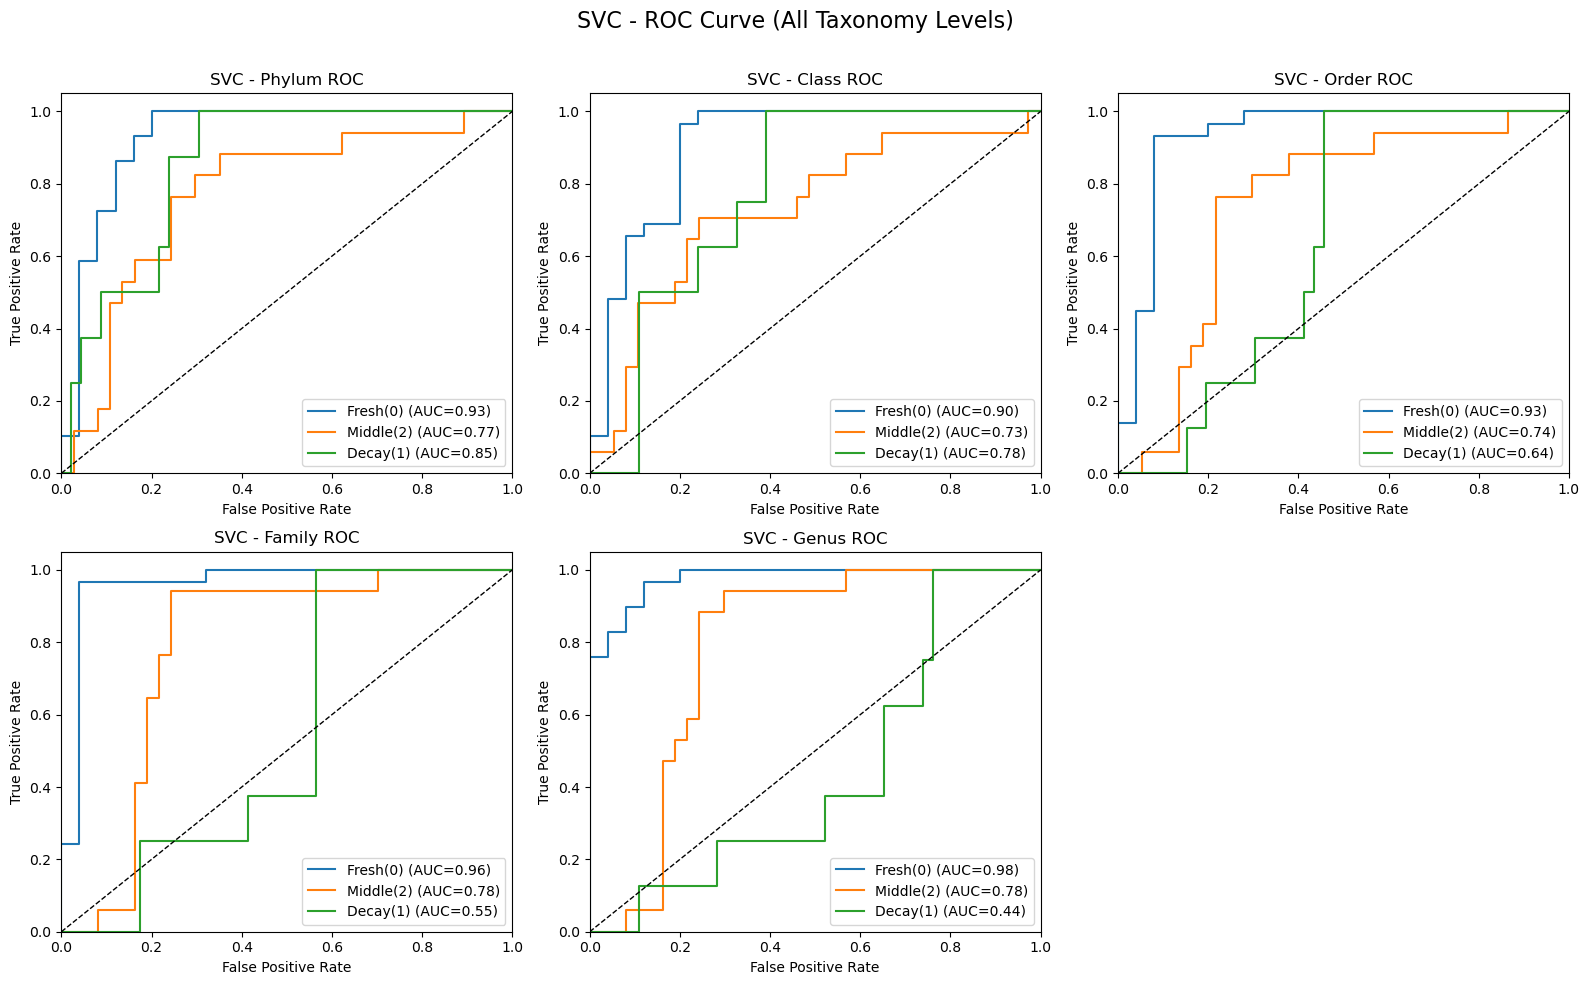

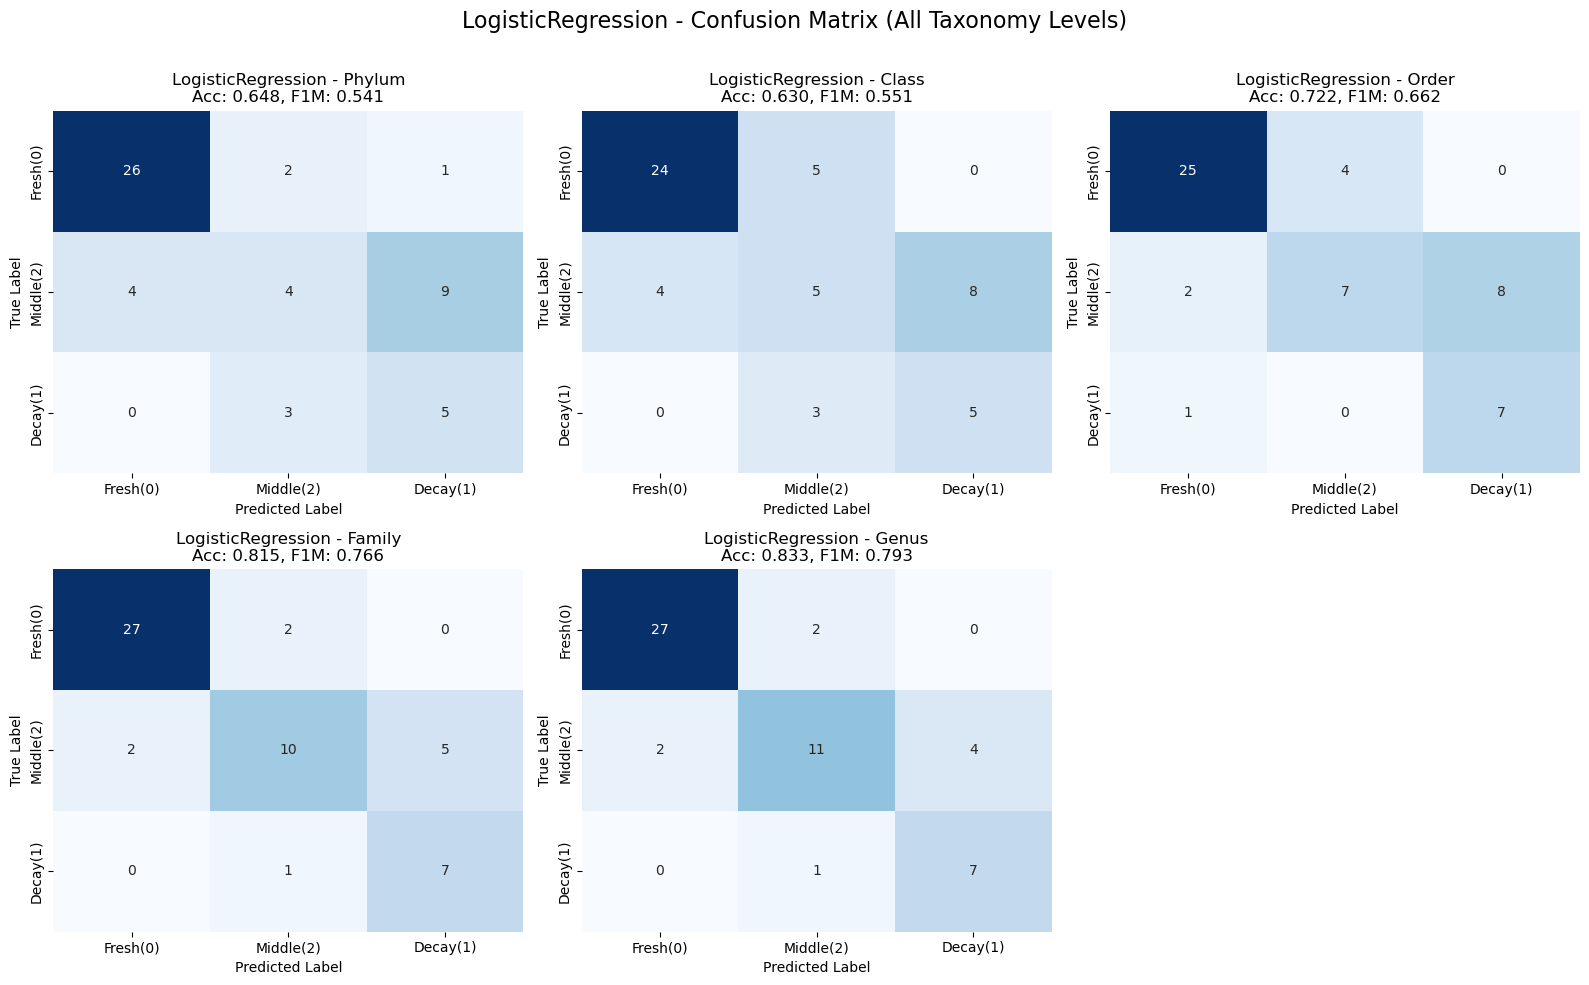

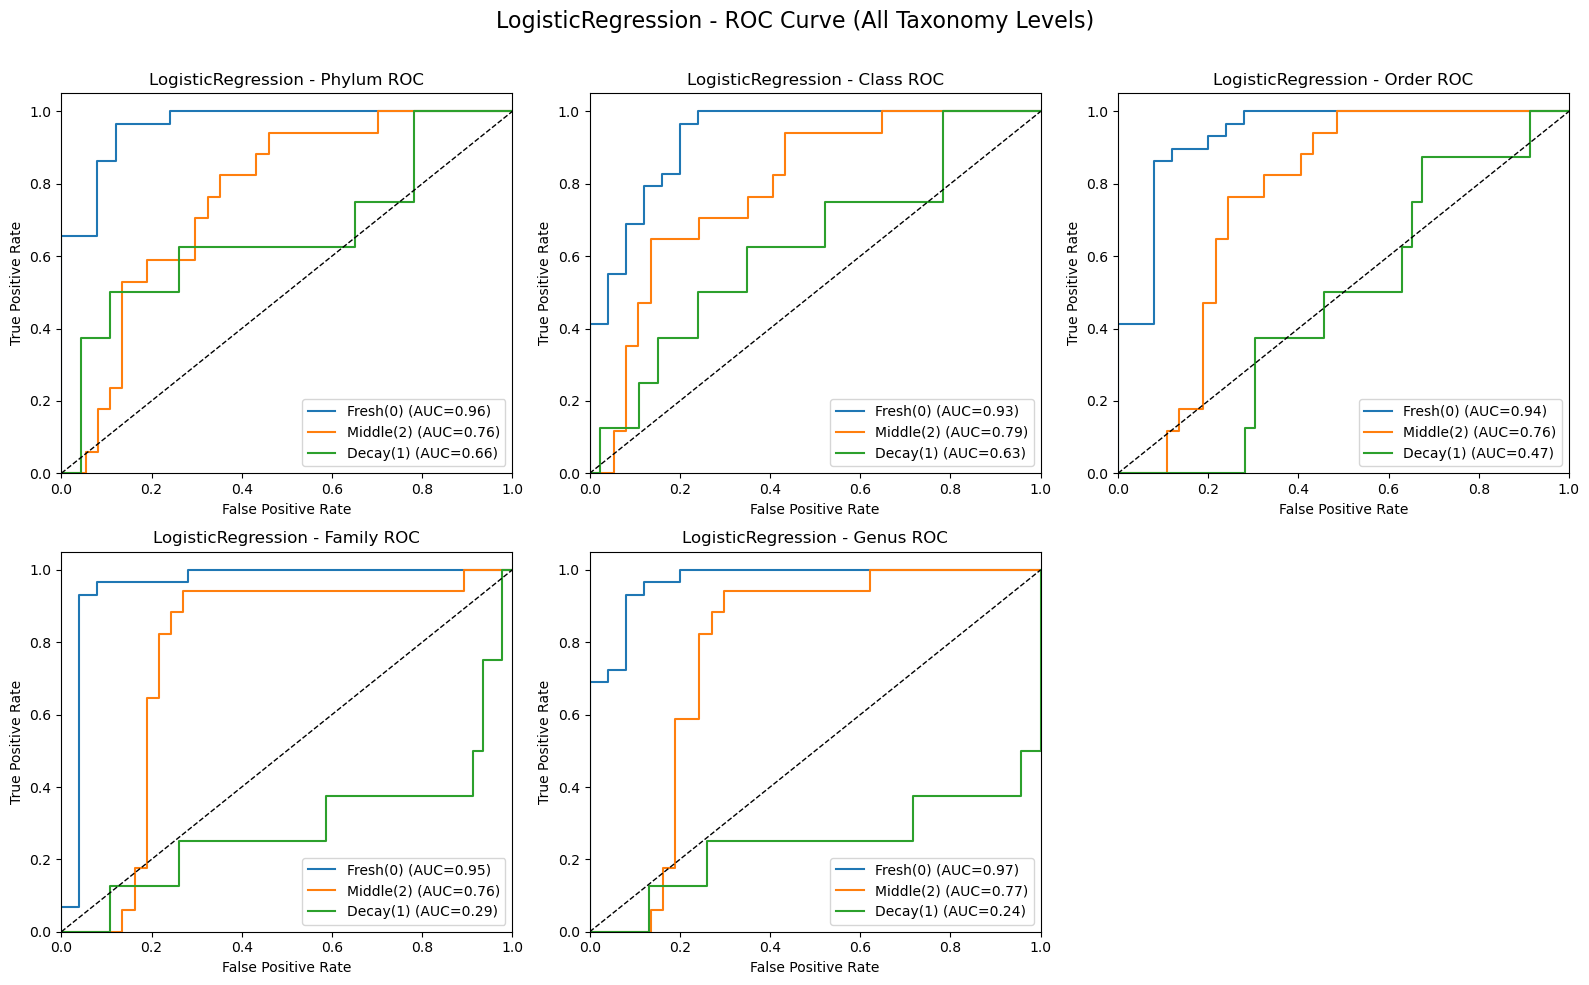

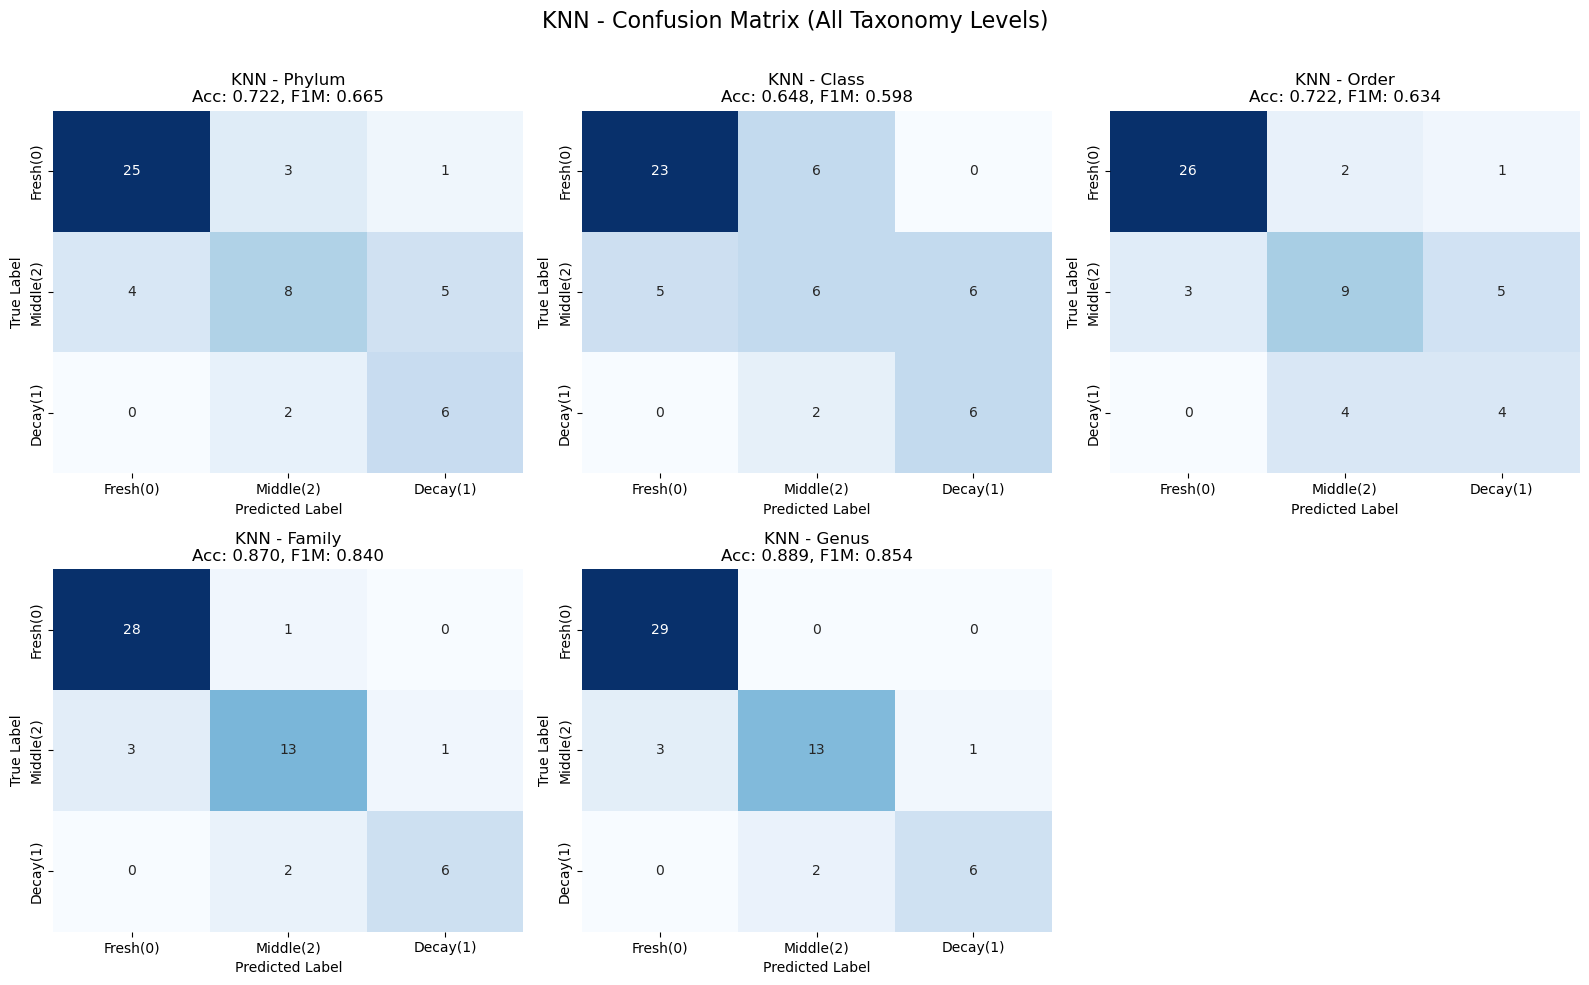

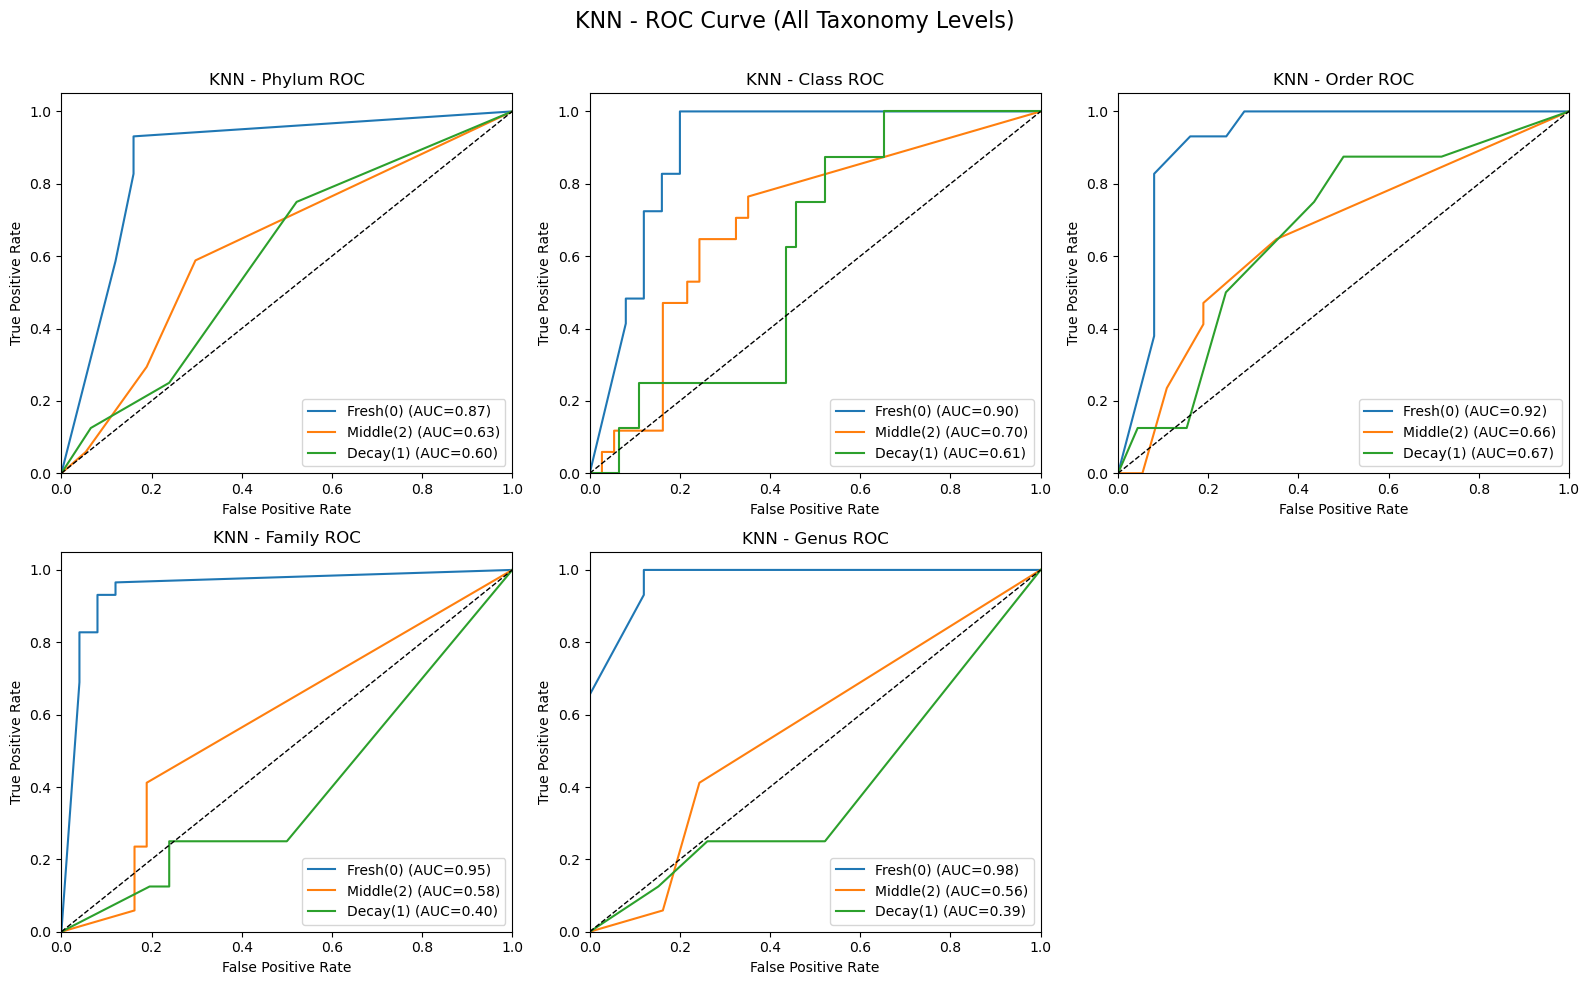

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

model_list = ["RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"]
taxonomy_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus']
label_order = [0, 2, 1]  # Fresh(0), Middle(2), Decay(1)
label_names = ["Fresh(0)", "Middle(2)", "Decay(1)"]

for model in model_list:
    # 1. Confusion Matrix (3x2 subplot)
    fig_cm, axes_cm = plt.subplots(2, 3, figsize=(16, 10))
    axes_cm = axes_cm.flatten()
    for i, level in enumerate(taxonomy_levels):
        best_model = all_model_results[level][model]["Best_Model"]
        level_data = final_taxonomic_levels_with_label[[x[0] for x in final_taxonomic_levels_with_label].index(level)][1]
        feature_cols = [col for col in level_data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
        X = level_data[feature_cols].values
        y = level_data['Label'].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        # 스케일러 적용 부분 삭제!
        y_pred = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=label_order)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_cm[i], cbar=False,
                    xticklabels=label_names, yticklabels=label_names)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro')
        axes_cm[i].set_title(f"{model} - {level}\nAcc: {acc:.3f}, F1M: {f1m:.3f}")
        axes_cm[i].set_xlabel("Predicted Label")
        axes_cm[i].set_ylabel("True Label")
    # 6번째 subplot은 빈칸
    axes_cm[5].axis('off')
    plt.suptitle(f"{model} - Confusion Matrix (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # 2. ROC Curve (3x2 subplot)
    fig_roc, axes_roc = plt.subplots(2, 3, figsize=(16, 10))
    axes_roc = axes_roc.flatten()
    for i, level in enumerate(taxonomy_levels):
        best_model = all_model_results[level][model]["Best_Model"]
        level_data = final_taxonomic_levels_with_label[[x[0] for x in final_taxonomic_levels_with_label].index(level)][1]
        feature_cols = [col for col in level_data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
        X = level_data[feature_cols].values
        y = level_data['Label'].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        # 스케일러 적용 부분 삭제!
        y_test_bin = label_binarize(y_test, classes=label_order)
        y_score = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None
        ax = axes_roc[i]
        if y_score is not None:
            for j in range(3):
                fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f"{label_names[j]} (AUC={roc_auc:.2f})")
            ax.plot([0, 1], [0, 1], 'k--', lw=1)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f"{model} - {level} ROC")
            ax.legend(loc="lower right")
        else:
            ax.text(0.5, 0.5, "No predict_proba", ha='center', va='center')
            ax.set_axis_off()
    # 6번째 subplot은 빈칸
    axes_roc[5].axis('off')
    plt.suptitle(f"{model} - ROC Curve (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## GridSearch CV 결과

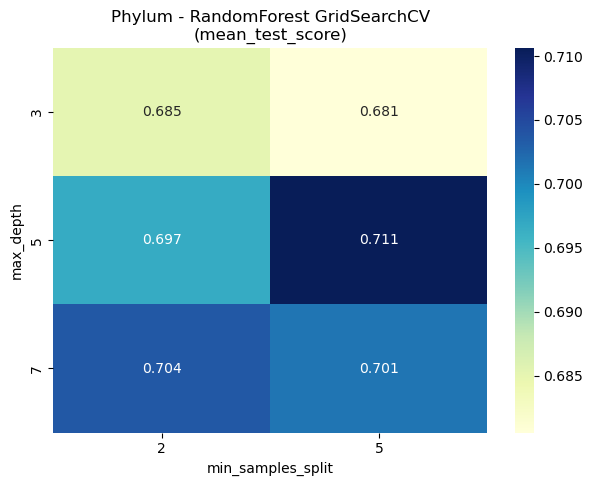

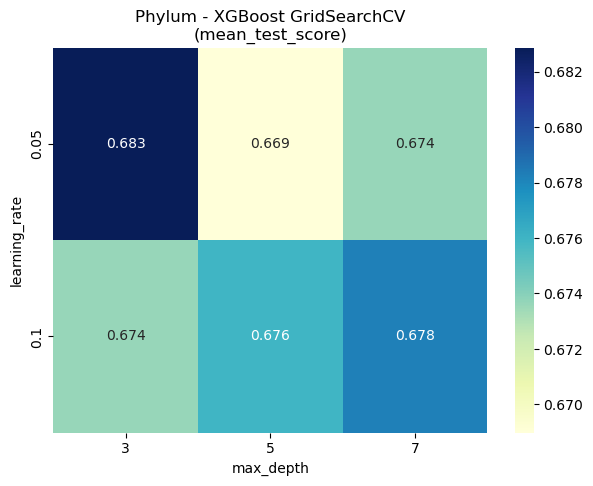

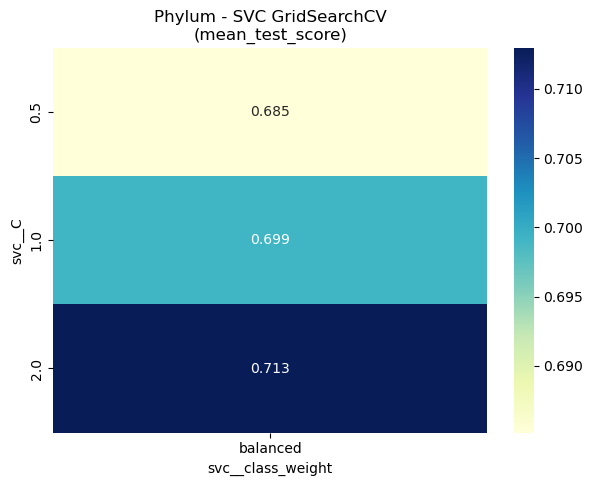

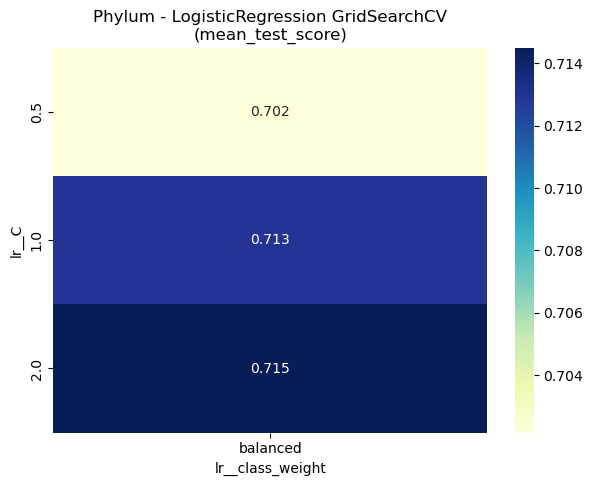

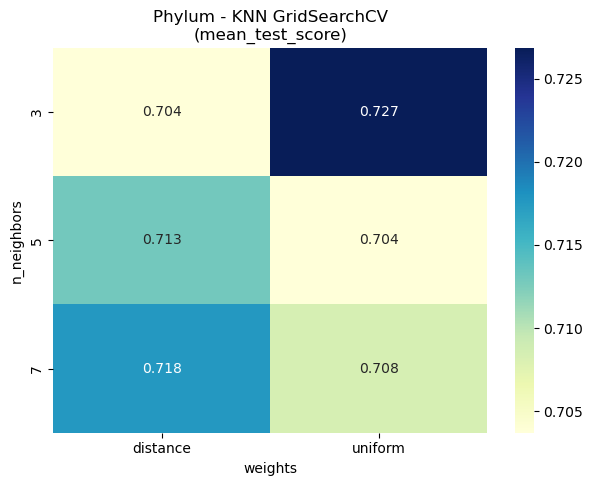

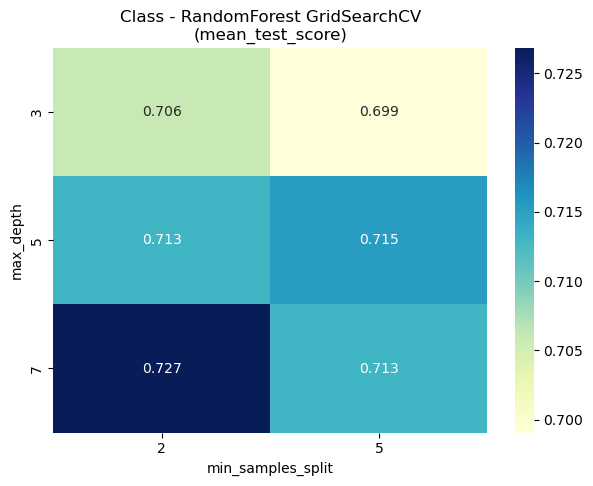

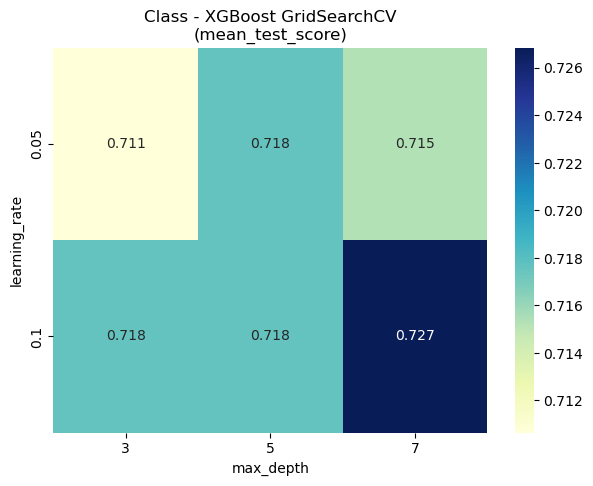

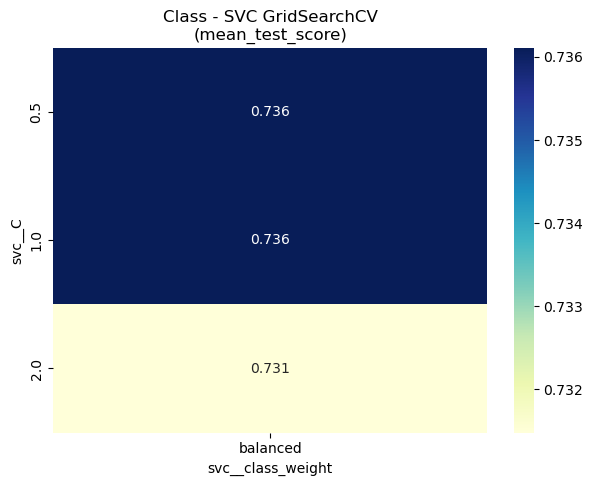

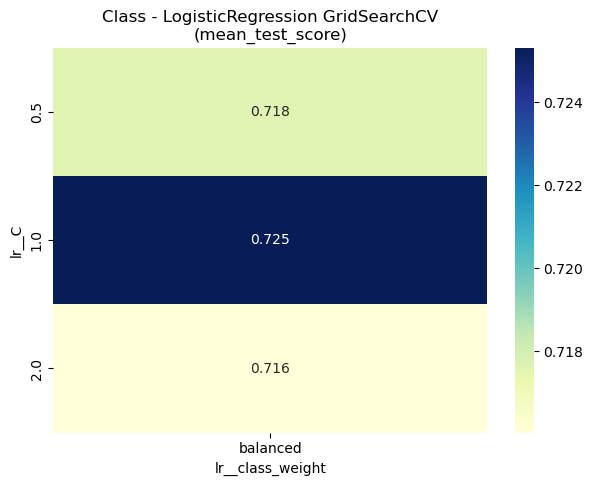

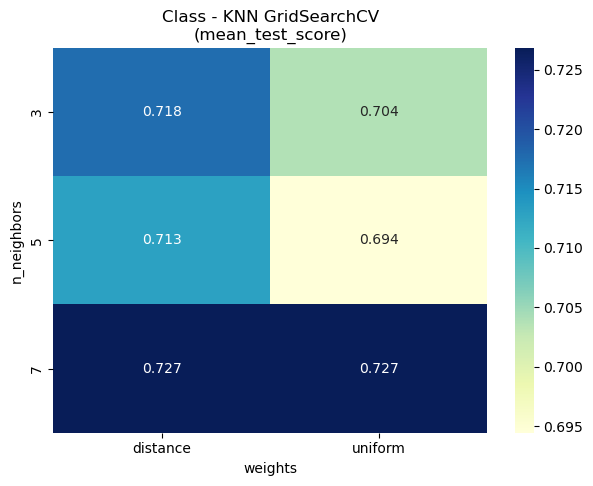

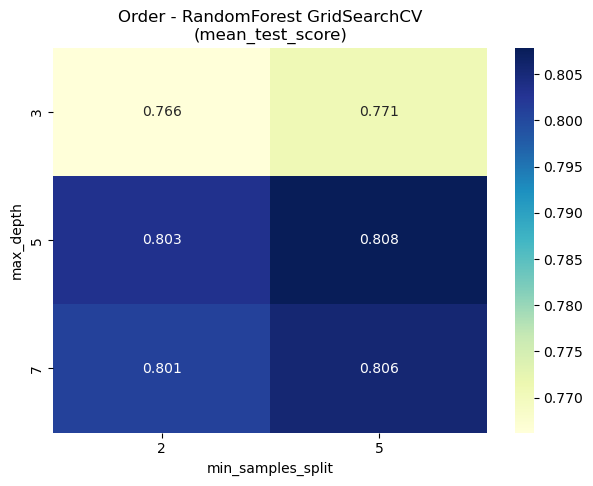

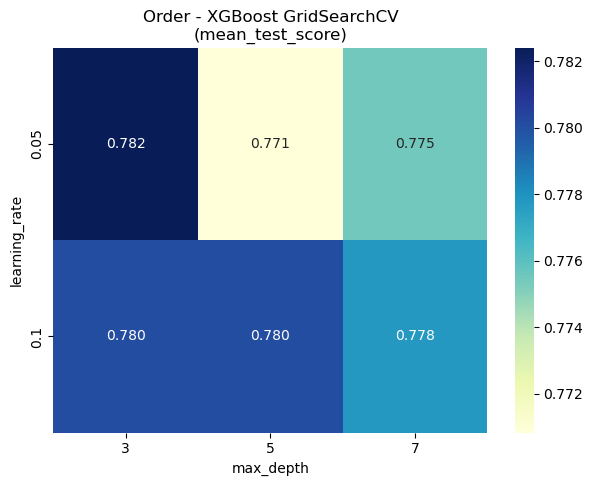

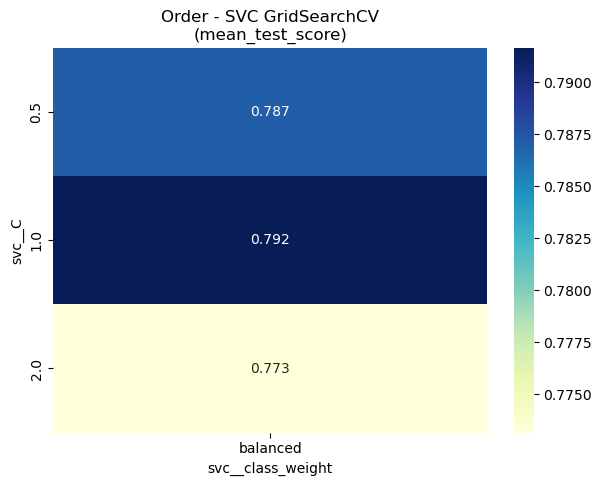

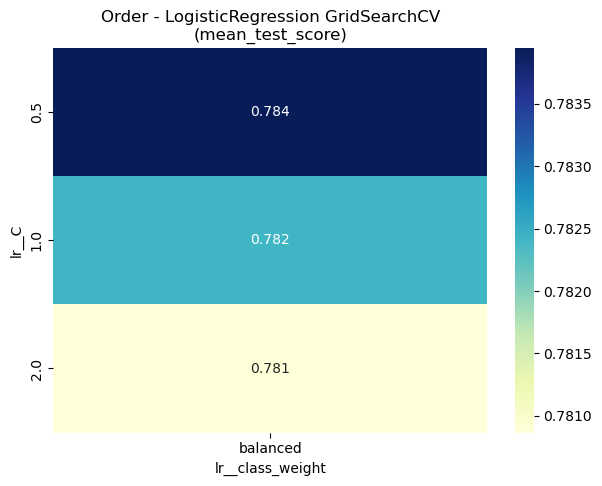

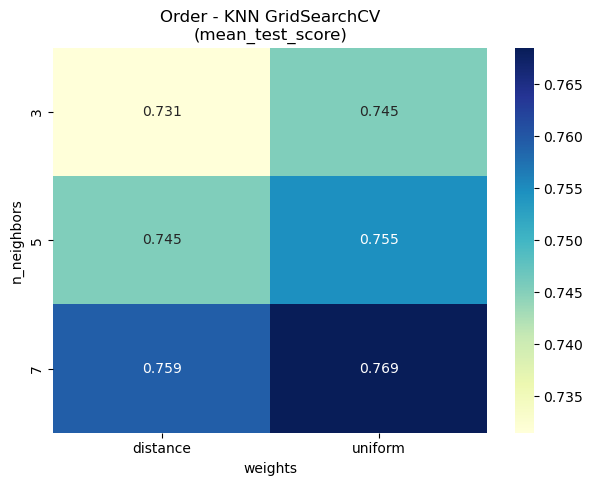

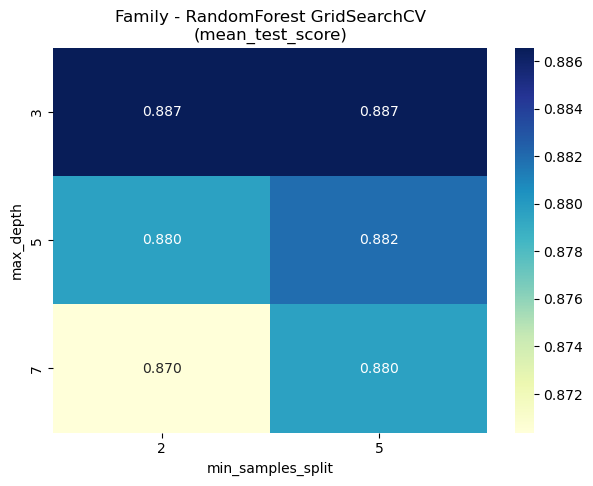

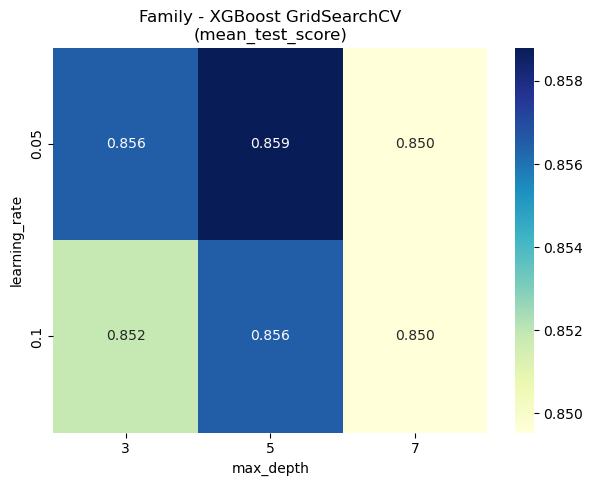

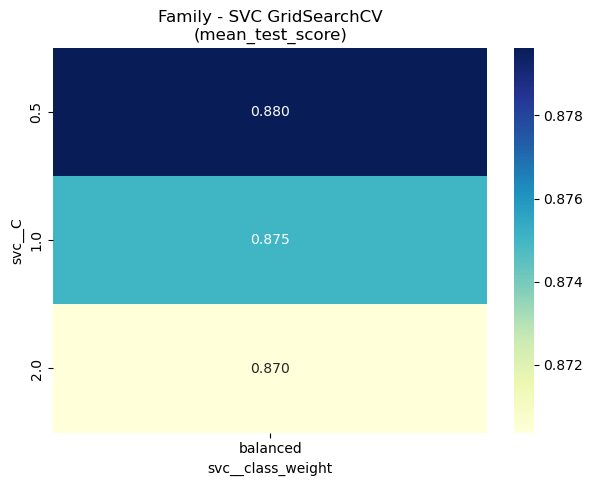

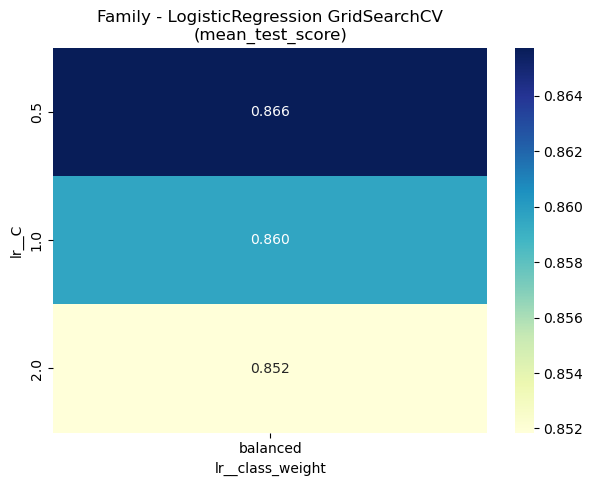

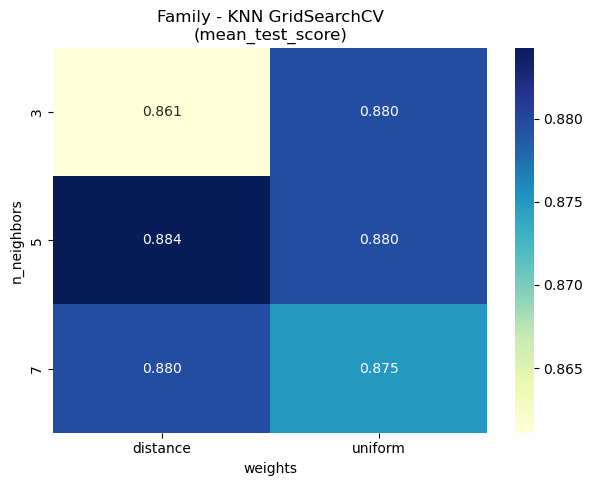

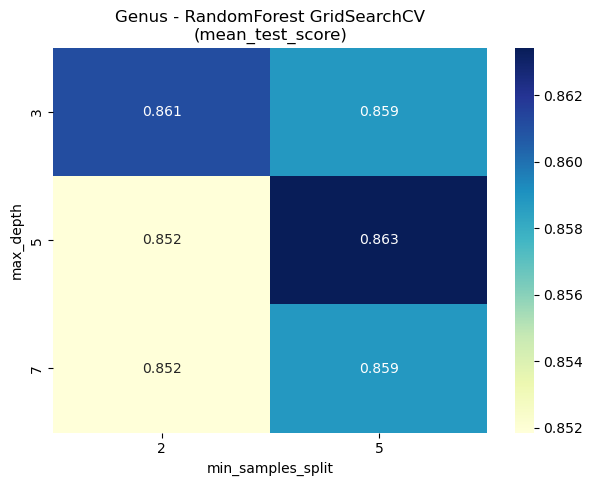

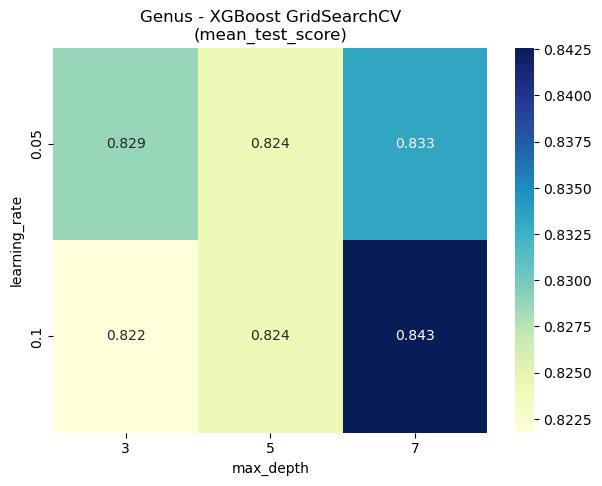

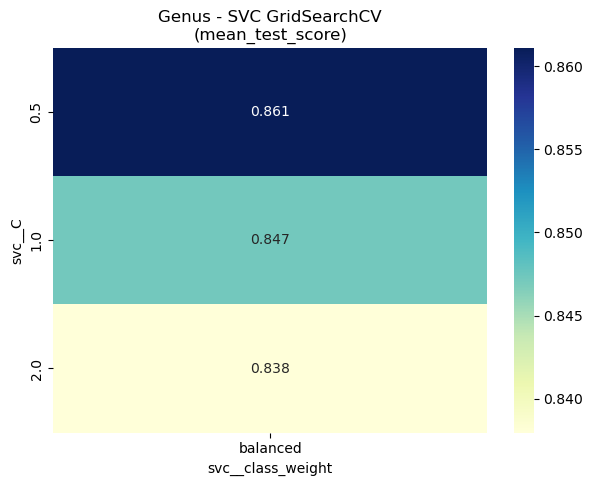

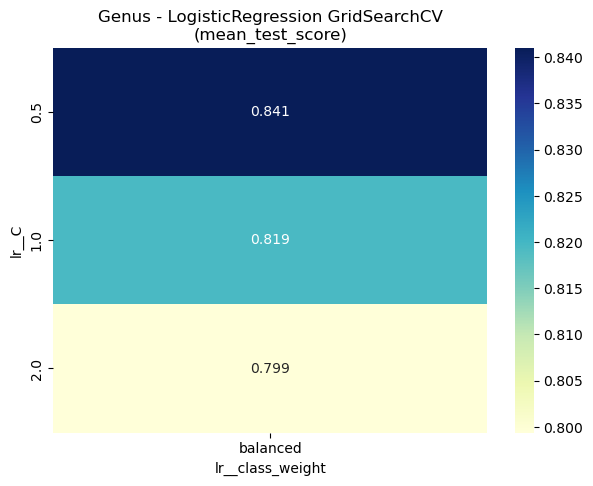

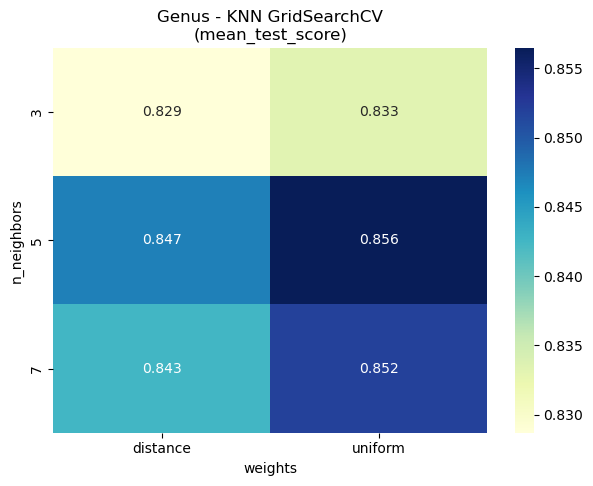

In [7]:
# GridSearch CV 결과 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# taxonomy level, 모델별로 GridSearchCV 결과 heatmap 시각화 (상위 2개 파라미터 기준)
for level_name in taxonomy_levels:
    for model_name in model_configs.keys():
        grid = all_model_results[level_name][model_name]["GridSearchCV"]
        param_results = grid.cv_results_
        params_df = pd.DataFrame(param_results)
        # 주요 파라미터 2개만 선택 (많으면 상위 2개만)
        param_keys = [k for k in grid.best_params_.keys()]
        if len(param_keys) > 2:
            param_keys = param_keys[:2]
        # 피벗 테이블 생성
        if len(param_keys) == 2:
            pivot = params_df.pivot_table(
                index=f'param_{param_keys[0]}',
                columns=f'param_{param_keys[1]}',
                values='mean_test_score'
            )
            plt.figure(figsize=(7,5))
            sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
            plt.title(f"{level_name} - {model_name} GridSearchCV\n(mean_test_score)")
            plt.xlabel(param_keys[1])
            plt.ylabel(param_keys[0])
            plt.show()
        else:
            # 파라미터가 1개일 때는 barplot
            plt.figure(figsize=(6,4))
            sns.barplot(
                x=params_df[f'param_{param_keys[0]}'],
                y=params_df['mean_test_score']
            )
            plt.title(f"{level_name} - {model_name} GridSearchCV\n(mean_test_score)")
            plt.xlabel(param_keys[0])
            plt.ylabel("mean_test_score")
            plt.show()

In [8]:
import os
import pandas as pd

result_dir = "model_result"
excel_path = os.path.join(result_dir, "gridsearch_best_params.xlsx")

best_params_rows = []
for level_name in taxonomy_levels:
    for model_name in model_configs.keys():
        grid = all_model_results[level_name][model_name]["GridSearchCV"]
        best_params = grid.best_params_
        row = {
            "Taxonomy_Level": level_name,
            "Model": model_name,
            "Best_Params": str(best_params)
        }
        best_params_rows.append(row)

df_best_params = pd.DataFrame(best_params_rows)
df_best_params.to_excel(excel_path, index=False)

print(f"GridSearchCV best parameter 결과가 '{excel_path}'에 저장되었습니다.")

GridSearchCV best parameter 결과가 'model_result/gridsearch_best_params.xlsx'에 저장되었습니다.
